In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:






#-------------------------------------------------ResNet-18 CNN---------------------------------------------------------------#







In [ ]:
# Imports
import os
import cv2
import glob
import numpy as np
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

# Fix truncated PNG errors
ImageFile.LOAD_TRUNCATED_IMAGES = True

# GPU check
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [ ]:
import os, glob
from sklearn.model_selection import train_test_split

ROOT = "/content/drive/MyDrive/RGBD/rgbd-dataset"
CLASSES = ["apple", "ball", "bowl", "cap", "soda_can"]

def collect_by_sequences(root=ROOT):
    data = {cls: {} for cls in CLASSES}

    for cls in CLASSES:
        class_dir = os.path.join(root, cls)
        if not os.path.exists(class_dir):
            continue

        sequences = sorted(os.listdir(class_dir))
        for seq in sequences:
            seq_path = os.path.join(class_dir, seq)
            pngs = glob.glob(seq_path + "/*.png")

            # exclude mask/depth
            pngs = [p for p in pngs if "_mask" not in p and "_depth" not in p]

            if len(pngs) > 0:
                data[cls][seq] = sorted(pngs)

    return data


data = collect_by_sequences()

train_paths = []
train_labels = []
test_paths = []
test_labels = []

for cls in CLASSES:
    seqs = list(data[cls].keys())
    if len(seqs) < 2:
        print(f"⚠️ {cls} has only {len(seqs)} sequence(s). Putting all in TRAIN.")
        for s in seqs:
            train_paths += data[cls][s]
            train_labels += [cls] * len(data[cls][s])
        continue

    train_seq, test_seq = train_test_split(seqs, test_size=0.2, random_state=42)

    for s in train_seq:
        train_paths += data[cls][s]
        train_labels += [cls] * len(data[cls][s])

    for s in test_seq:
        test_paths += data[cls][s]
        test_labels += [cls] * len(data[cls][s])


print("Train samples:", len(train_paths))
print("Test samples:", len(test_paths))



Train samples: 9167
Test samples: 4394


In [ ]:
#Dataset class

class RGBDDataset(Dataset):
    def __init__(self, paths, labels, classes, transform=None):
        self.paths = paths
        self.labels = labels
        self.classes = classes
        self.class_to_idx = {c:i for i,c in enumerate(classes)}
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]

        # Convert class name → index
        label = self.class_to_idx[self.labels[idx]]

        # Read image safely
        try:
          img = Image.open(img_path).convert("RGB")
        except:
            img = Image.new("RGB", (224,224))

        if self.transform:
            img = self.transform(img)

        return img, label




In [ ]:
#Transform and dataload
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

CLASSES = ["apple", "ball", "bowl", "cap", "soda_can"]

train_dataset = RGBDDataset(train_paths, train_labels, CLASSES, transform)
test_dataset  = RGBDDataset(test_paths, test_labels, CLASSES, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))


Train batches: 287
Test batches: 138


In [ ]:
#Modeling
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

model.fc = nn.Linear(512, len(CLASSES))  # 5 classes

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
print(os.listdir("/content/drive/MyDrive/RGBD/rgbd-dataset/cap"))
print(os.listdir("/content/drive/MyDrive/RGBD/rgbd-dataset/soda_can"))


['cap_4', 'cap_1', 'cap_2']
['soda_can_1', 'soda_can_3', 'soda_can_4', 'soda_can_6', 'soda_can_5', 'soda_can_2']


In [ ]:
#Remove Duplicate Images

import os, hashlib
ROOT = "/content/drive/MyDrive/RGBD/rgbd-dataset"

def md5(path, blocksize=2**20):
    h = hashlib.md5()
    with open(path,'rb') as f:
        while True:
            b = f.read(blocksize)
            if not b: break
            h.update(b)
    return h.hexdigest()

hash_to_paths = {}
for cls in os.listdir(ROOT):
    class_dir = os.path.join(ROOT, cls)
    if not os.path.isdir(class_dir): continue
    for root, dirs, files in os.walk(class_dir):
        for f in files:
            if f.lower().endswith(".png"):
                full = os.path.join(root,f)
                h = md5(full)
                hash_to_paths.setdefault(h, []).append(full)

dups = {h:ps for h,ps in hash_to_paths.items() if len(ps)>1}
print("Number of duplicate-image groups:", len(dups))
# print a few groups
for i,(h,ps) in enumerate(dups.items()):
    if i>5: break
    print("=== group", i, "hash", h)
    for p in ps: print(" ", p)


Number of duplicate-image groups: 165
=== group 0 hash 0d911e0367579031c7854ce340fac868
  /content/drive/MyDrive/RGBD/rgbd-dataset/ball/ball_7/ball_7_1_20.png
  /content/drive/MyDrive/RGBD/rgbd-dataset/ball/ball_7/ball_7_1_21.png
=== group 1 hash aeec454d125071b315a093da3268407b
  /content/drive/MyDrive/RGBD/rgbd-dataset/ball/ball_7/ball_7_1_24.png
  /content/drive/MyDrive/RGBD/rgbd-dataset/ball/ball_7/ball_7_1_25.png
=== group 2 hash 0f64ca77b007086c93d1ee2a0537c465
  /content/drive/MyDrive/RGBD/rgbd-dataset/ball/ball_7/ball_7_1_46.png
  /content/drive/MyDrive/RGBD/rgbd-dataset/ball/ball_7/ball_7_1_47.png
=== group 3 hash 685ef4476635ca704b63631952e0b6be
  /content/drive/MyDrive/RGBD/rgbd-dataset/ball/ball_7/ball_7_1_60.png
  /content/drive/MyDrive/RGBD/rgbd-dataset/ball/ball_7/ball_7_1_61.png
=== group 4 hash efa3796ee9e16d6f592a650288713c52
  /content/drive/MyDrive/RGBD/rgbd-dataset/ball/ball_7/ball_7_1_72.png
  /content/drive/MyDrive/RGBD/rgbd-dataset/ball/ball_7/ball_7_1_73.png
==

In [ ]:
import os, glob, hashlib
from sklearn.model_selection import train_test_split

ROOT = "/content/drive/MyDrive/RGBD/rgbd-dataset"
CLASSES = ["apple", "ball", "bowl", "cap", "soda_can"]

def md5(path, blocksize=2**20):
    h = hashlib.md5()
    with open(path,'rb') as f:
        while True:
            b = f.read(blocksize)
            if not b: break
            h.update(b)
    return h.hexdigest()

# 1) Load all sequences + images
data = {c:{} for c in CLASSES}
for c in CLASSES:
    cdir = os.path.join(ROOT, c)
    if not os.path.isdir(cdir): continue

    for seq in sorted(os.listdir(cdir)):
        sp = os.path.join(cdir, seq)
        if not os.path.isdir(sp): continue
        imgs = glob.glob(sp + "/*.png")
        imgs = [p for p in imgs if "_mask" not in p and "_depth" not in p]
        if imgs:
            data[c][seq] = sorted(imgs)

# 2) Remove duplicates INSIDE EACH sequence (but keep one)
removed = 0
for c in CLASSES:
    for seq, imgs in data[c].items():
        seen = {}
        unique = []
        for img in imgs:
            h = md5(img)
            if h not in seen:
                seen[h] = img
                unique.append(img)
            else:
                removed += 1
        data[c][seq] = unique

print("Removed duplicates inside sequences:", removed)

# 3) Sequence-level train/test split
train_paths, train_labels = [], []
test_paths, test_labels = [], []

for c in CLASSES:
    seqs = list(data[c].keys())
    if len(seqs) == 0:
        continue

    if len(seqs) < 3:
        train_seq = seqs[:-1]
        test_seq = seqs[-1:]
    else:
        train_seq, test_seq = train_test_split(seqs, test_size=0.2, random_state=42)

    for s in train_seq:
        train_paths += data[c][s]
        train_labels += [c] * len(data[c][s])

    for s in test_seq:
        test_paths += data[c][s]
        test_labels += [c] * len(data[c][s])

print("Train size:", len(train_paths))
print("Test size:", len(test_paths))

# 4) Final leakage check
train_hashes = {md5(p) for p in train_paths}
test_hashes = {md5(p) for p in test_paths}

print("Cross-split duplicates:", len(train_hashes & test_hashes))


Removed duplicates inside sequences: 165
Train size: 9034
Test size: 4362
Cross-split duplicates: 0


In [ ]:
#Training

from sklearn.metrics import accuracy_score

EPOCHS = 10

train_losses = []
test_accs = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # ---- Evaluation ----
    model.eval()
    all_preds, all_true = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            preds = torch.argmax(out, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_true.extend(labels.cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    test_accs.append(acc)

    print(f"Epoch {epoch+1}/{EPOCHS}  Loss={train_losses[-1]:.4f}  Acc={acc:.4f}")


Epoch 1/10  Loss=0.0220  Acc=0.9989
Epoch 2/10  Loss=0.0004  Acc=0.9995
Epoch 3/10  Loss=0.0002  Acc=0.9991
Epoch 4/10  Loss=0.0001  Acc=0.9991
Epoch 5/10  Loss=0.0001  Acc=1.0000
Epoch 6/10  Loss=0.0001  Acc=0.9998
Epoch 7/10  Loss=0.0000  Acc=0.9998
Epoch 8/10  Loss=0.0000  Acc=1.0000
Epoch 9/10  Loss=0.0000  Acc=1.0000
Epoch 10/10  Loss=0.0000  Acc=1.0000


In [ ]:
print("\nFINAL ACCURACY:", accuracy_score(all_true, all_preds))
print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=CLASSES))


FINAL ACCURACY: 1.0

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00       607
        ball       1.00      1.00      1.00       783
        bowl       1.00      1.00      1.00      1162
         cap       1.00      1.00      1.00       628
    soda_can       1.00      1.00      1.00      1214

    accuracy                           1.00      4394
   macro avg       1.00      1.00      1.00      4394
weighted avg       1.00      1.00      1.00      4394



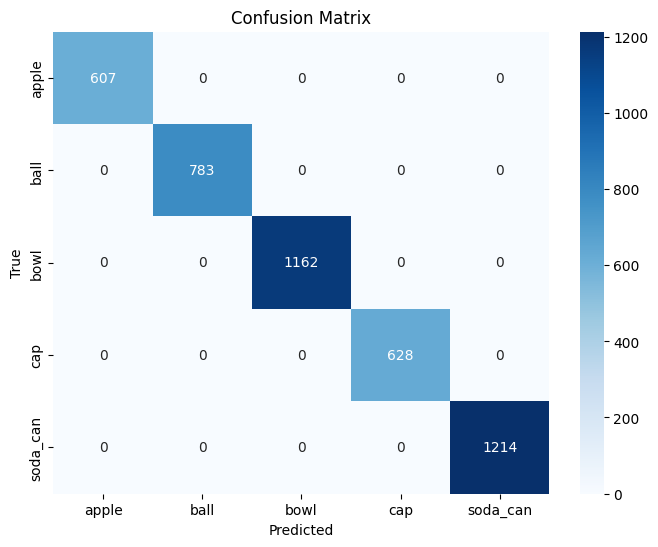

In [ ]:
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:







#------------------------------ORB + Bag of Visual Words (BoVW) + SVM------------------------------------------------------------------#








In [ ]:
import cv2
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# 1. ORB Feature Extraction Function

def extract_orb_descriptors(image_paths, max_kp=500):
    orb = cv2.ORB_create(nfeatures=max_kp)
    all_desc = []

    print("Extracting ORB descriptors...")

    for p in image_paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        kp, des = orb.detectAndCompute(img, None)
        if des is not None:
            all_desc.append(des)

    return all_desc

In [ ]:
# Build Vocabulary (K-Means on descriptors)

def build_vocabulary(des_list, vocab_size=500):
    print("Stacking descriptors...")
    stacked = np.vstack(des_list)   # shape [N_descriptors, 32]

    print("Clustering descriptors (MiniBatchKMeans)...")
    kmeans = MiniBatchKMeans(n_clusters=vocab_size,
                             batch_size=2000,
                             max_iter=100,
                             verbose=1)
    kmeans.fit(stacked)

    return kmeans

In [ ]:
# Convert images → histogram features

def compute_bow_histograms(kmeans, image_paths, max_kp=500):
    orb = cv2.ORB_create(nfeatures=max_kp)
    vocab_size = kmeans.n_clusters

    histograms = []

    print("Computing histograms for", len(image_paths), "images...")

    for p in image_paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            histograms.append(np.zeros(vocab_size))
            continue

        kp, des = orb.detectAndCompute(img, None)

        if des is None:
            histograms.append(np.zeros(vocab_size))
            continue

        words = kmeans.predict(des)
        hist, _ = np.histogram(words, bins=np.arange(vocab_size+1))
        histograms.append(hist)

    return np.array(histograms)

In [ ]:
#ORB + SVM Pipeline
# -----------------------------------------

# Extract ORB descriptors from training images only
train_des = extract_orb_descriptors(train_paths)

# Build vocabulary
VOCAB_SIZE = 600
kmeans = build_vocabulary(train_des, vocab_size=VOCAB_SIZE)

# Compute BoW histograms
X_train = compute_bow_histograms(kmeans, train_paths)
X_test  = compute_bow_histograms(kmeans, test_paths)

# Train SVM classifier
print("Training SVM...")
svm = SVC(kernel="linear", probability=True)
svm.fit(X_train, train_labels)

print("SVM trained.")

Extracting ORB descriptors...
Stacking descriptors...
Clustering descriptors (MiniBatchKMeans)...
Init 1/1 with method k-means++
Inertia for init 1/1: 555088592.0
[MiniBatchKMeans] Reassigning 64 cluster centers.
Minibatch step 1/205597: mean batch inertia: 92366.844
Minibatch step 2/205597: mean batch inertia: 82443.18208878218, ewa inertia: 82443.18208878218
Minibatch step 3/205597: mean batch inertia: 79438.3574562305, ewa inertia: 82440.25906568185
Minibatch step 4/205597: mean batch inertia: 77130.26866398989, ewa inertia: 82435.09363125399
Minibatch step 5/205597: mean batch inertia: 75705.8562377489, ewa inertia: 82428.54758655782
Minibatch step 6/205597: mean batch inertia: 75577.50225743369, ewa inertia: 82421.88304995175
Minibatch step 7/205597: mean batch inertia: 73318.4585496368, ewa inertia: 82413.0274515856
Minibatch step 8/205597: mean batch inertia: 73538.46275437831, ewa inertia: 82404.39448268143
Minibatch step 9/205597: mean batch inertia: 74217.28395732857, ewa ine

In [ ]:
# Evaluate
pred = svm.predict(X_test)

print("\nAccuracy:", accuracy_score(test_labels, pred))
print("\nClassification Report:\n")
print(classification_report(test_labels, pred))


Accuracy: 0.9440623567171023

Classification Report:

              precision    recall  f1-score   support

       apple       0.96      1.00      0.98       607
        ball       1.00      1.00      1.00       751
        bowl       0.99      0.97      0.98      1162
         cap       1.00      0.66      0.79       628
    soda_can       0.86      1.00      0.92      1214

    accuracy                           0.94      4362
   macro avg       0.96      0.93      0.94      4362
weighted avg       0.95      0.94      0.94      4362



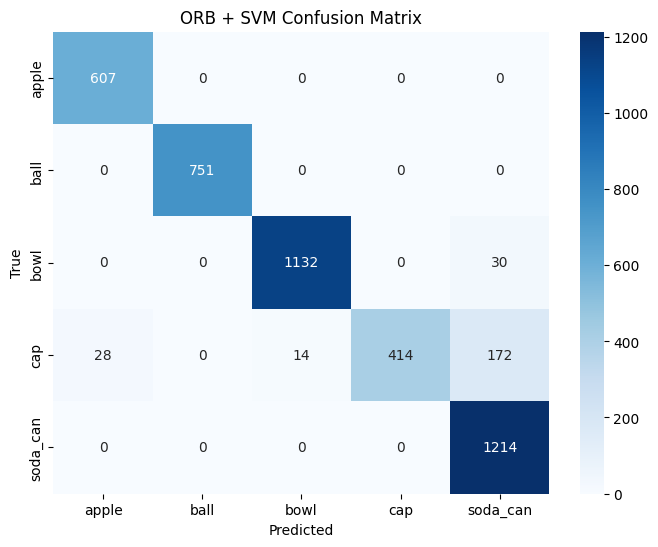

In [ ]:
cm = confusion_matrix(test_labels, pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("ORB + SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:











#---------------------------------------------Comparison plots--------------------------------------------------------------------------













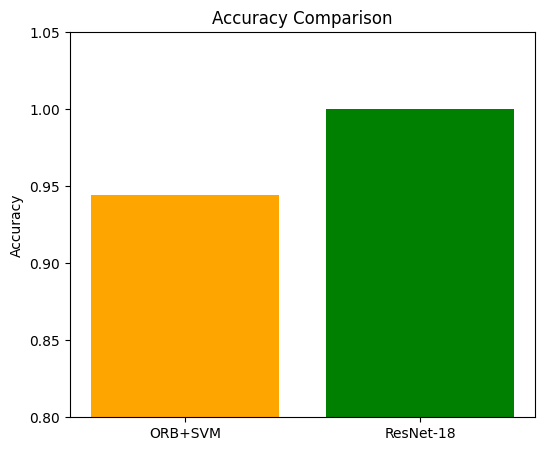

In [ ]:
#Accuracy Comparison
import matplotlib.pyplot as plt

orb_acc = accuracy_score(test_labels, pred)
cnn_acc = accuracy_score(all_true, all_preds)

plt.figure(figsize=(6,5))
plt.bar(["ORB+SVM", "ResNet-18"], [orb_acc, cnn_acc], color=["orange", "green"])
plt.ylim(0.8, 1.05)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


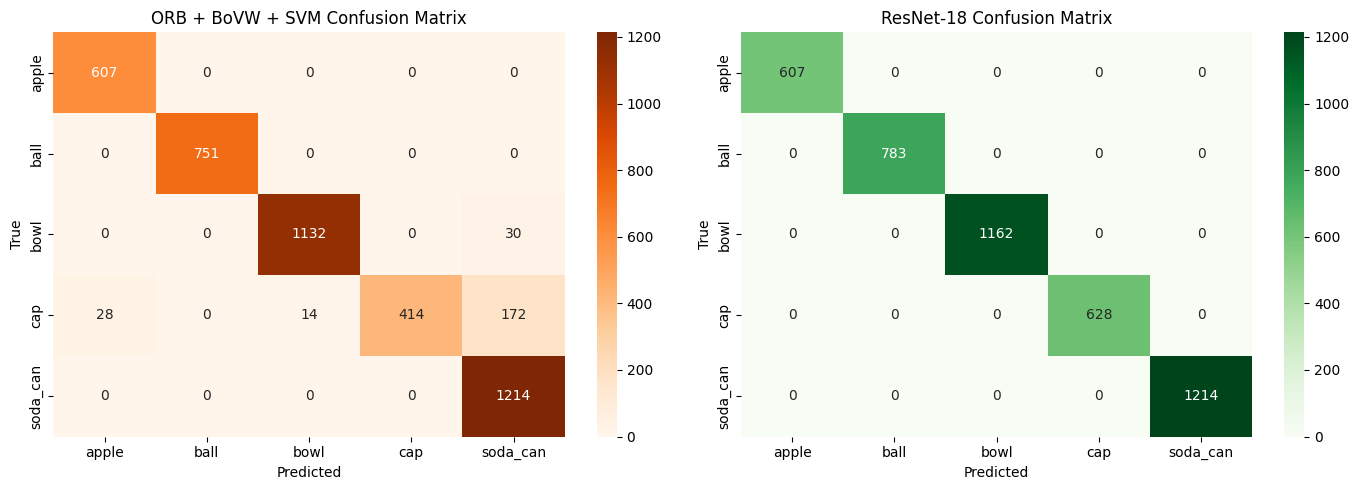

In [ ]:
#Confusion Matrix Comaprison
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ORB confusion matrix
cm_orb = confusion_matrix(test_labels, pred)
sns.heatmap(cm_orb, annot=True, fmt="d", cmap="Oranges",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title("ORB + BoVW + SVM Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# CNN confusion matrix
cm_cnn = confusion_matrix(all_true, all_preds)
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title("ResNet-18 Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()


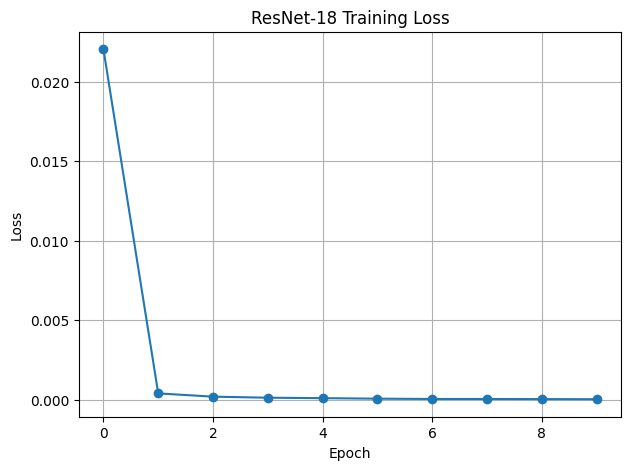

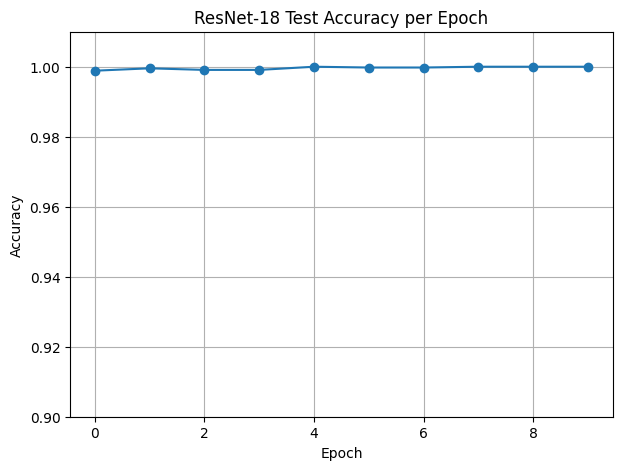

In [ ]:
#CNN Training Curve

# Training Loss
plt.figure(figsize=(7,5))
plt.plot(train_losses, marker="o")
plt.title("ResNet-18 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()


# Test Accuracy
plt.figure(figsize=(7,5))
plt.plot(test_accs, marker="o")
plt.title("ResNet-18 Test Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.01)
plt.grid()
plt.show()


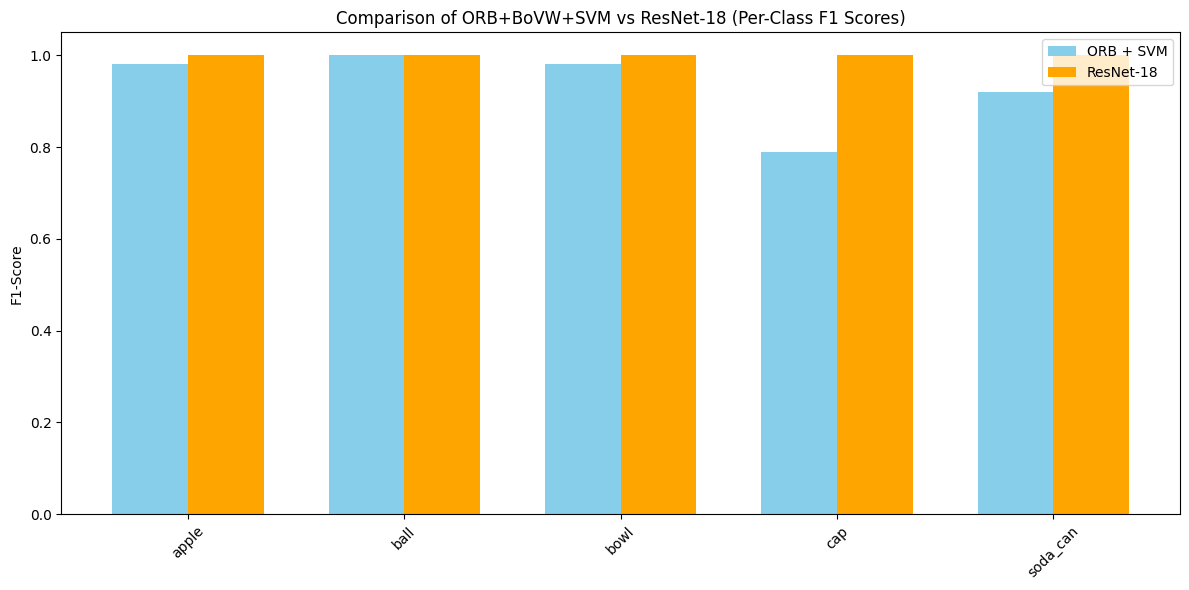

In [ ]:
#Per class F1 Score Comparison

CLASSES = ["apple", "ball", "bowl", "cap", "soda_can"]

test_labels = {
    "apple": 0.98,
    "ball": 1.00,
    "bowl": 0.98,
    "cap": 0.79,
    "soda_can": 0.92
}
all_true = {
    "apple": 1.00,
    "ball": 1.00,
    "bowl": 1.00,
    "cap": 1.00,
    "soda_can": 1.00
}

pred = [test_labels[c] for c in CLASSES]
all_preds = [all_true[c] for c in CLASSES]


# ---- Plot ----
x = np.arange(len(CLASSES))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, pred, width, label="ORB + SVM", color="skyblue")
plt.bar(x + width/2, all_preds, width, label="ResNet-18", color="orange")

plt.xticks(x, CLASSES, rotation=45)
plt.ylabel("F1-Score")
plt.title("Comparison of ORB+BoVW+SVM vs ResNet-18 (Per-Class F1 Scores)")
plt.legend()
plt.tight_layout()
plt.show()

